In [1]:
#Import modules
import sys
import os
print(os.getcwd())
sys.path.append('../')
sys.path.append('../modules/')
from Class_sem2dpack import *
from Stage_module import *
from houches_fb import *
from scipy.interpolate import griddata
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as anim

#Load data
direct1 = "C:/Users/t.guyonneau/OneDrive - EGIS Group/Documents/OUTPUT/Preno_Volvi"
is_overburden = False
fmin, fmax = 0.01, 50.0
SEM = sem2dpack(direct1)


c:\Users\t.guyonneau\OneDrive - EGIS Group\Documents\GitHub\sem2dpack\JUPYTER\Stage_Theo
Reading grid information...
Reading header file...
0.00019999999 35001 1661
--- No extra station ---
*


c:\Users\t.guyonneau\OneDrive - EGIS Group\Documents\GitHub\sem2dpack\JUPYTER\Stage_Theo\..\Class_sem2dpack.py:330: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  line = pd.read_csv(fname, delim_whitespace=True, header=None, nrows=1, dtype=int)
c:\Users\t.guyonneau\OneDrive - EGIS Group\Documents\GitHub\sem2dpack\JUPYTER\Stage_Theo\..\Class_sem2dpack.py:331: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(fname, names=('x','z'), delim_whitespace=True, header=0, nrows=line.values[0][0])
c:\Users\t.guyonneau\OneDrive - EGIS Group\Documents\GitHub\sem2dpack\JUPYTER\Stage_Theo\..\Class_sem2dpack.py:365: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(fname, header=0, n

Filtering seissmograms ...
Filtering seissmograms ...


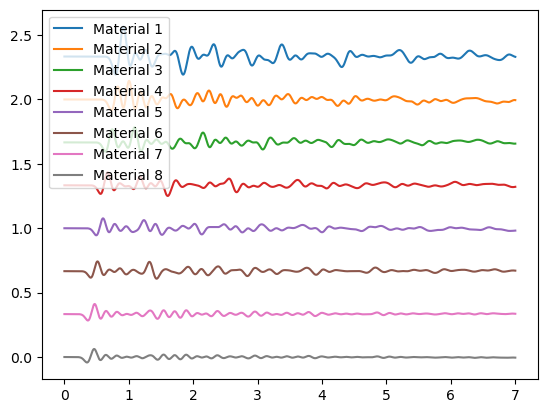

In [2]:
SEM.read_seismo('x')
SEM.filter_seismo(fmax=fmax, ftype='lowpass')
SEM.filter_seismo(fmin=fmin, ftype='highpass')
Time_stations = SEM.time
Vx = SEM.velocity[:,:]
XSTA, ZSTA = SEM.rcoord[:,0], SEM.rcoord[:,1]
#plt.scatter(XSTA, ZSTA, marker='v')


s1 = get_nearest_station(0,-3.5,XSTA,ZSTA)
s2 = get_nearest_station(0,-13.5,XSTA,ZSTA)
s3 = get_nearest_station(0,-37,XSTA,ZSTA)
s4 = get_nearest_station(0,-65.75,XSTA,ZSTA)
s5 = get_nearest_station(0,-102.5,XSTA,ZSTA)
s6 = get_nearest_station(0,-157,XSTA,ZSTA)
s7 = get_nearest_station(0,-191.5,XSTA,ZSTA)
s8 = get_nearest_station(0,-248.25,XSTA,ZSTA)

#plt.scatter(XSTA[[s1,s2,s3,s4,s5,s6,s7,s8]], ZSTA[[s1,s2,s3,s4,s5,s6,s7,s8]], marker='v')

stations = [s1,s2,s3,s4,s5,s6,s7,s8]

for i in range(len(stations)): 
    plt.plot(Time_stations,Vx[:,stations[i]]+(7-i)/3,label=f"Material {i+1}")
plt.legend()
plt.show()

c:\Users\t.guyonneau\OneDrive - EGIS Group\Documents\GitHub\sem2dpack\JUPYTER\Stage_Theo\../modules\Stage_module.py:263: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax_F.set_xlim(0,50)


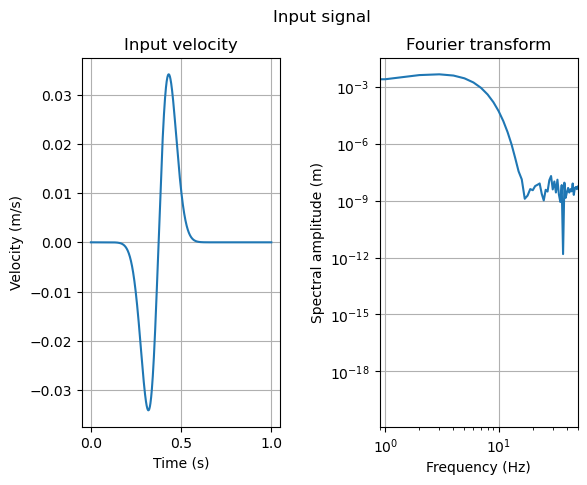

In [5]:
plot_input_signal(SEM, 'VF')

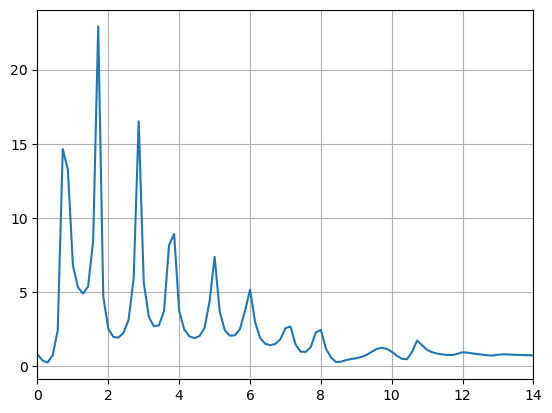

In [4]:
dt = Time_stations[1]-Time_stations[0]
FFT1, freq = fourier(Vx[:,s1],dt)
FFT8, freq = fourier(Vx[:,s8],dt)
plt.plot(freq,FFT1/FFT8)
plt.xlim([0,14])
plt.grid(True)